# Моделирование параметров прибытия подразделений пожарной охраны

## Общие сведения

Моделирование параметров прибытия подразделений пожарной охраны - одна из основных частей работы с библиотекой **Генезис**, в которой при помощи расчетных алгоритмов и с использованием исходных данных происходит моделирование параметров прибытия подразделений пожарной охраны.

Результатом моделирования является текущее состояние параметров прибытия пожарных подразделений - времена прибытия первого подразделения пожарной охраны во все узлы ГДС и идентификатор первого прибывающего подразделения пожарной охраны.

В наиболее общем виде структуру моделирования можно представить следующим образом:

```{mermaid}
flowchart LR

  state["**ФУНКЦИЯ МОДЕЛИРОВАНИЯ**"]

  source["**ИСХОДНЫЕ ДАННЫЕ**"]

  algs["**РАСЧЕТНЫЕ АЛГОРИТМЫ**
        ---
        Кратчайший путь
        ---
        Модель оценки t_сл"]


  model("**МОДЕЛИРОВАНИЕ
          ПАРАМЕТРОВ
          ПРИБЫТИЯ**")
  
  result["**РЕЗУЛЬТАТЫ**"]

  algs --> state
  state --> model
  source --> model
  model --> result

```

При конструировании решения пользователю, исходя из поставленной задачи расчета, необходимо: 

1. Выбрать функцию моделирования
2. Указать используемые функцией моделирования (*как правило достаточно установленных по умолчанию*):
  - алгоритм расчета кратчайшего пути
  - алгоритм расчета времени следования ПА
3. Выбрать исходные данные которые следует использовать:
  - ГДС *(всегда)*
  - дислокация ПСЧ
  - расчетная область
  - скоростной режим *(всегда)*

### Алгоритмы моделирования {.unnumbered}

В **Генезис** реализованы следующие алгоритмы:

- `genesis.states.FirstArrivalUnitState`: алгоритм расчета на основе определения времени прибытия от каждой указанной ПСЧ до каждого из узлов ГДС по кратчайшему маршруту (прямая задача)
- `genesis.states.ArrivalTimeMatrixState`: алгоритм расчета на основе заранее рассчитанной матрицы прибытия к каждому из узлов ГДС (обратная задача)

## Примеры использования

Загрузка основных библиотек

In [ ]:
import random

import osmnx as ox
import pandas as pd
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\nContextily', ctx.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
Contextily 1.6.2


### Пример 1: Моделирование параметров прибытия во все узлы графа {.unnumbered}

**Задача**: Определить параметры прибытия подразделений пожарной охраны во все узлы ГДС

In [ ]:
from genesis.states import FirstArrivalUnitState
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}


## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)


# 2. Сборка решения
## Выбор алгоритма моделирования 
## (алгоритмы расчета расчета кратчайшего пути
## и времени следования установлены по умолчанию)
state = FirstArrivalUnitState()

# 3. Моделирование параметров прибытия
times, nearest = state(env=G, points=units_dict)


# Печать случайных 3 результатов по временам прибытия и ближайшим подразделениям
nodes = random.choices(times.keys(), k=3)
times[nodes], nearest[nodes]

(1025675392    11.725953
 1044634307     4.474972
 7652383878    17.613312
 Name: times, dtype: float64,
 1025675392    3 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...
 1044634307    4 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...
 7652383878    2 ПСЧ 1 ПСО  ФПС ГПС ГУ МЧС России по Кемеровс...
 Name: nearest, dtype: object)

`times` -- данные о временах прибытия первого подразделения пожарной охраны в каждый из узлов ГДС

`nearest` -- идентификатор первого прибывающего подразделения

Ключ, словаря - это идентификатор узла ГДС, значение - время прибытия первого подразделения и его идентификатор для `times` и `nearest`, соответственно. Таким образом `1025675392    11.725953`, означает что в узел `1025675392` первое подразделение прибудет через `6,5 минут`. А запись `(1025675392, "3 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...")` означает, что первым подразделением будет `3 ПСЧ 1 ПСО ФПС ГПС ГУ МЧС России по Кемеровск...`

:::{.callout-important}

#### Важно

На практике не всегда все узлы ГДС достижимы, поэтому количество `times` и `nearest` может быть меньше чем количество графов

:::

Взглянуть на некоторые характеристики полученного распределения времен прибытия можно воспользовавшись `describe()`

In [ ]:
times.describe()

count    54915.000000
mean        10.248943
std          5.993978
min          1.000000
25%          5.752797
50%          8.213621
75%         14.116574
max         35.690362
Name: times, dtype: float64

Видно, что среднее время прибытия первого пожарного подразделения составляет 10,2 мин, максимальное - 35,6 мин.

Графически оценить распределение времен прибытия можно построив гистограмму распределения.

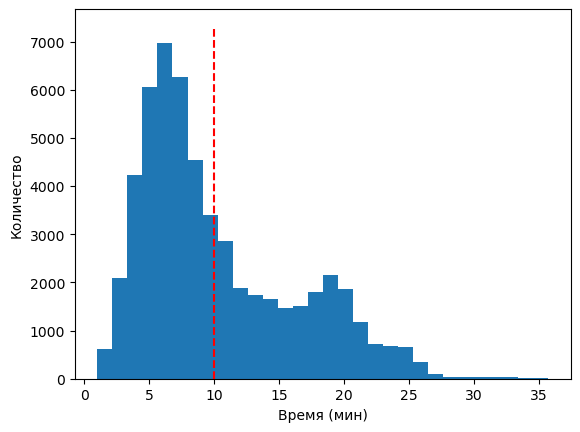

In [14]:
ax = times.plot(kind='hist', bins=30)
ax.set_xlabel('Время (мин)')
ax.set_ylabel('Количество')
ax.vlines(10, 0, ax.get_ylim()[1], colors='red', linestyles='dashed')

Можно также оценить долю значений, время прибытия которых превышает 10 и 20 минут (ИП-10 и ИП-20)

In [19]:
print('ИП-10:', 100 * sum(times<=10) / len(times))
print('ИП-10:', 100 * sum(times<=20) / len(times))

ИП-10: 60.92142401893836
ИП-10: 91.04069926249659


Наконец, очевидный интерес представляет визуализация времен прибытия и первого прибывшего подразделения пожарной охраны на карте населенного пункта.

<Axes: >

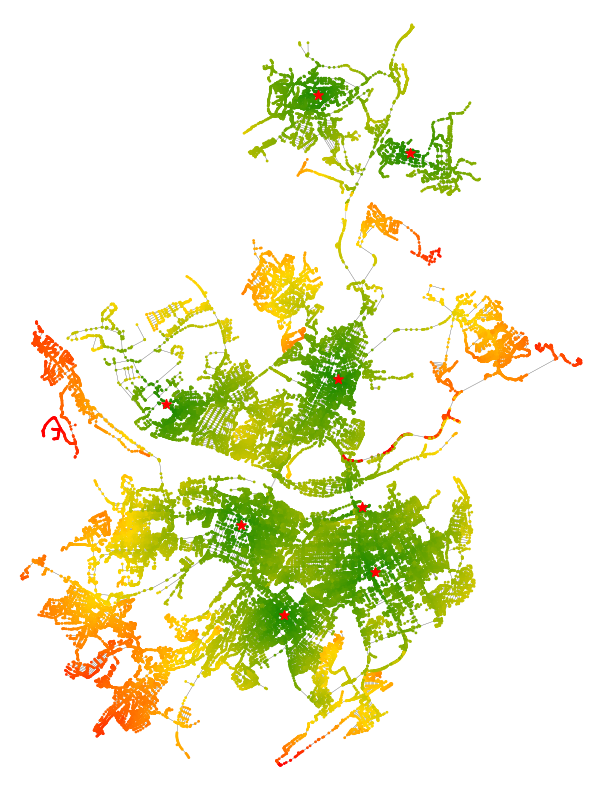

In [38]:
from genesis.swiss_knife import CMAP_GrGldRd    # Цветовая карта Зеленый-Красный

# Получение набора геоданных узлов ГДС
g_nodes = ox.graph_to_gdfs(G, edges=False)

# Дополняем геоданные результатами моделирования
g_nodes = g_nodes.merge(times, left_index=True, right_index=True)
g_nodes = g_nodes.merge(nearest, left_index=True, right_index=True)

# Печатаем узлы как градиент
fig, ax = plt.subplots(figsize=(10,10))
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax, close=False, show=False)
g_nodes.plot(column='times', ax=ax, cmap=CMAP_GrGldRd, markersize=1, vmin=0, vmax=30) 
units.plot(ax=ax, color='red', markersize=50, marker='*', label='Пожарные подразделения')

Однако интереснее было бы взглянуть на зоны прикрытые подразделениями пожарной охраны и зоны обслуживания ПСЧ

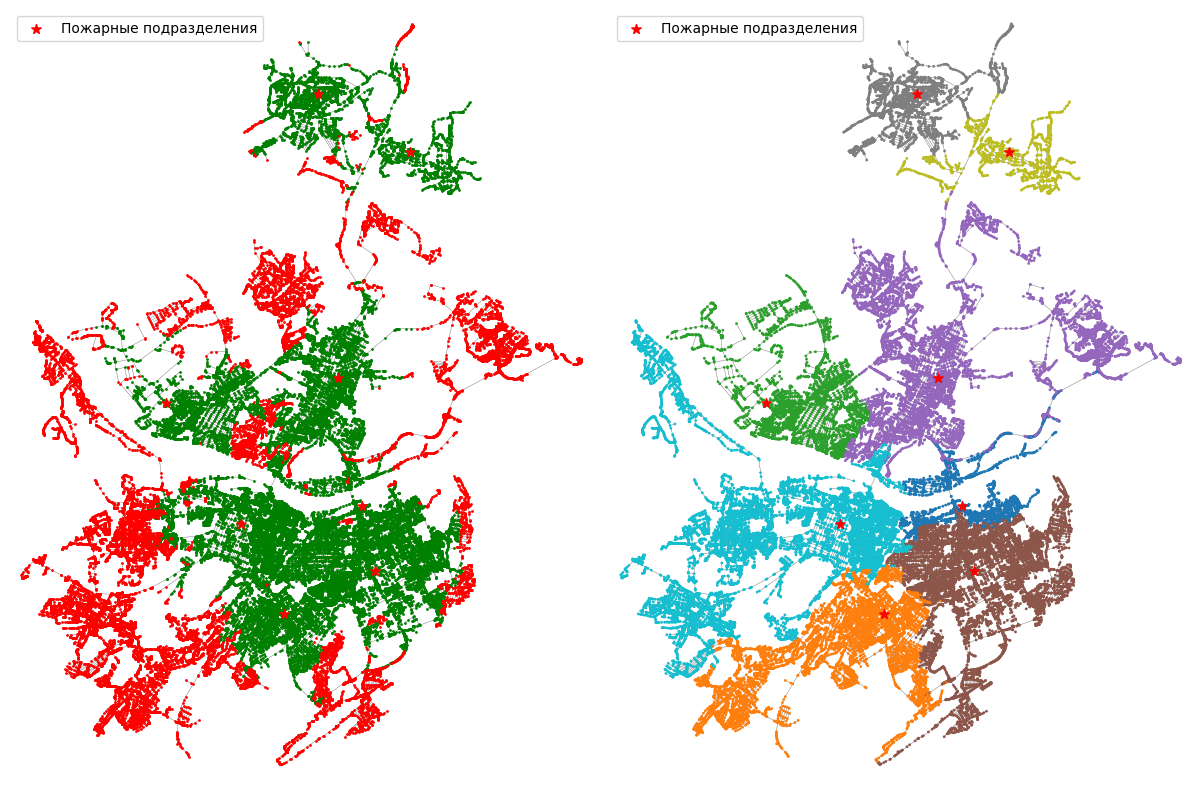

In [43]:
# Подготовка холста для 2 карт
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8), tight_layout=True)

# Карта 10 минутной зоны
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax1, close=False, show=False)
g_nodes[g_nodes['times']<=10].plot(ax=ax1, markersize=1, color='g') 
g_nodes[g_nodes['times']>10].plot(ax=ax1, markersize=1, color='r')
units.plot(ax=ax1, color='red', markersize=50, marker='*', label='Пожарные подразделения')
ax1.legend()

# Карта зон обслуживания
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax2, close=False, show=False)
g_nodes.plot(ax=ax2, column='nearest', markersize=1)
units.plot(ax=ax2, color='red', markersize=50, marker='*', label='Пожарные подразделения')
ax2.legend()

Боле подробно о способах визуализации карт при помощи Python можно прочитать в разделе "Для разработчиков".

### Пример 2: Моделирование в пределах некоторой области {.unnumbered}

Зачастую возникает ситуация когда требуется произвести расчет для некоторого населенного пункта и при этом необходимо учитывать возможность следования ПА за пределами населенного пункта. В такой ситуации нельзя учитывать узлы ГДС расположенные за пределами границ населенного пункта.

В этом случае необходимо указывать дополнительно маску узлов ГДС, которые следует учитывать в расчетах.

<Axes: >

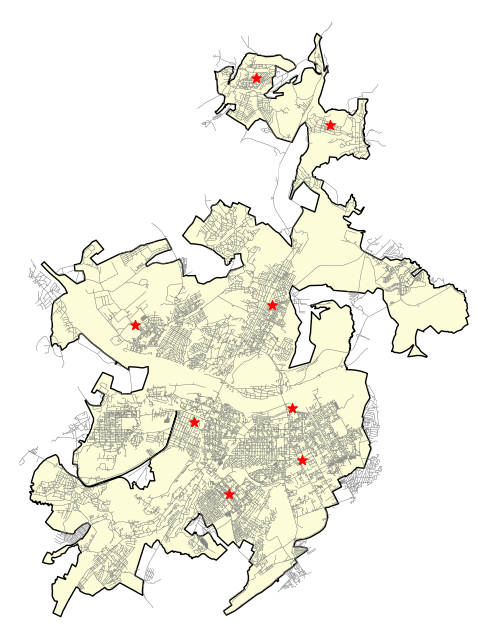

In [51]:
# Загрузка границ населенного пункта
borders = gpd.read_file('data/kemerovo/borders.gpkg')

# Печать ГДС и границ населенного пункта
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax, close=False, show=False)
units.plot(ax=ax, color='red', markersize=50, marker='*', label='Пожарные подразделения')

Видно, что в данном случае часть ГДС находится за пределами границ населенного пункта и учитывать их в качестве возможных мест возникновения пожара тоже не требуется.

В этом случае моделирование выполняется только для узлов расположенных в пределах населенного пункта:

In [61]:
# Получение маски узлов графа (потенциальных мест возникновения пожара)
nodes_mask = g_nodes.within(borders.union_all())

# 3. Моделирование параметров прибытия
times, nearest = state(env=G, points=units_dict, area=nodes_mask)
times.describe()

count    48675.000000
mean         9.588211
std          5.566273
min          1.000000
25%          5.521719
50%          7.687040
75%         12.798064
max         33.472722
Name: times, dtype: float64

Видно, что размер `times` = 48675, в то время, как ранее размер результатов моделирования составлял 54915.

При этом теперь среднее время прибытия составляет 9,6 минут, против 10,2 минут ранее.

Взглянем как теперь выглядит карта населенного пункта:

<Axes: >

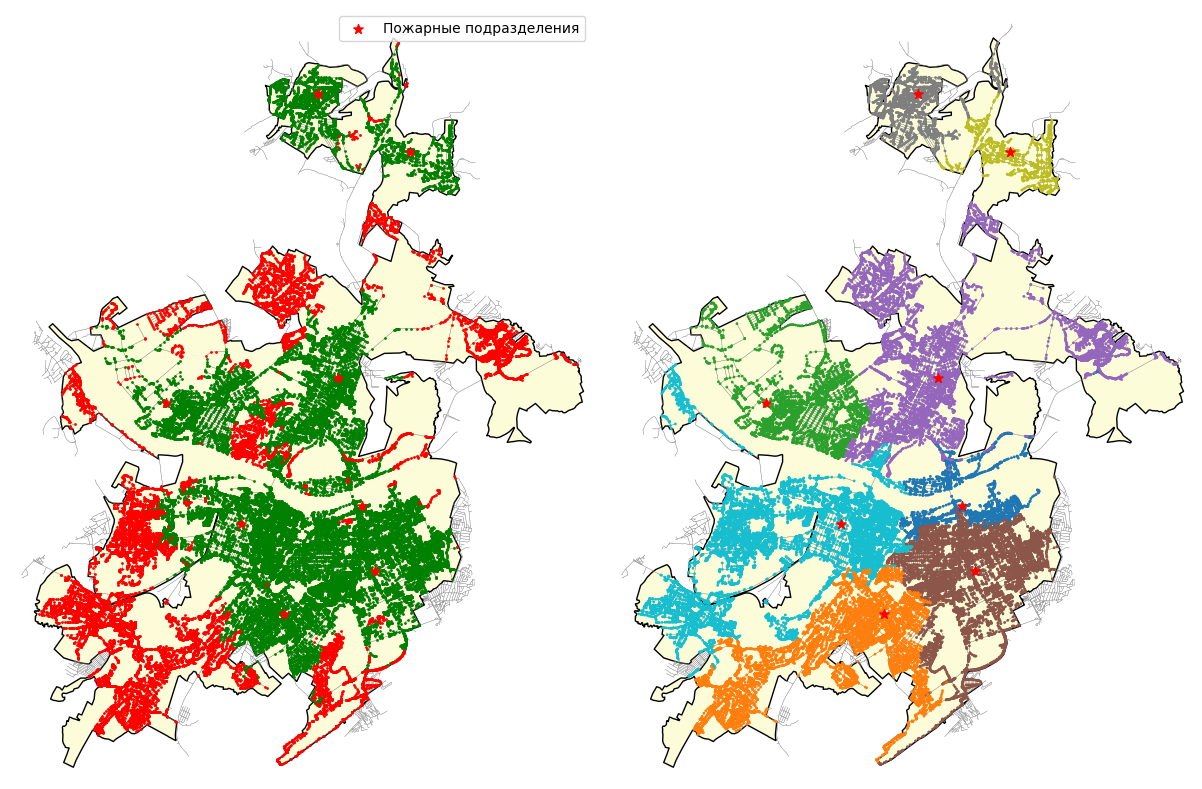

In [63]:
# Получение набора геоданных узлов ГДС
g_nodes = ox.graph_to_gdfs(G, edges=False)

# Дополняем геоданные результатами моделирования
g_nodes = g_nodes.merge(times, left_index=True, right_index=True)
g_nodes = g_nodes.merge(nearest, left_index=True, right_index=True)


# Подготовка холста для 2 карт
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8), tight_layout=True)

# Карта 10 минутной зоны
borders.plot(ax=ax1, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax1, close=False, show=False)
g_nodes[g_nodes['times']<=10].plot(ax=ax1, markersize=1, color='g') 
g_nodes[g_nodes['times']>10].plot(ax=ax1, markersize=1, color='r')
units.plot(ax=ax1, color='red', markersize=50, marker='*', label='Пожарные подразделения')
ax1.legend()

# Карта зон обслуживания
borders.plot(ax=ax2, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax2, close=False, show=False)
g_nodes.plot(ax=ax2, column='nearest', markersize=1)
units.plot(ax=ax2, color='red', markersize=50, marker='*', label='Пожарные подразделения')

Можно заметить, что узлы ГДС выходящие за пределы границ населенного пункта на карте теперь не отмечены.

### Пример 3: Моделирование параметров прибытия к зданиям {.unnumbered}

Реализованные в **Генезис** функции моделирования ориентированы на расчет времени прибытия к узлам ГДС. Предполагается, что дальнейший анализ будет выполняться либо инструментами анализа, либо внутренней логикой эвристических алгоритмов, либо пользователем.

Поэтому напрямую указать функциям моделирования здания в качестве цели нельзя.

Для моделирования параметров прибытия именно к зданиям населенного пункта, следует объединить набор пространственных данных о зданиях с результатами моделирования, аналогично тому, как выше происходило объединение с данными узлах ГДС.

In [ ]:
from genesis.states import FirstArrivalUnitState
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Загрузка зданий
buildings = gpd.read_file('data/kemerovo/buildings.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
### Для полигональных объектов следует использовать центроиды: `geometry.centroid`
buildings['node'] = ox.distance.nearest_nodes(G, 
                                              buildings.geometry.centroid.x,
                                              buildings.geometry.centroid.y
                                              )



## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)


# 2. Сборка решения
## Выбор алгоритма моделирования 
## (алгоритмы расчета расчета кратчайшего пути
## и времени следования установлены по умолчанию)
state = FirstArrivalUnitState()


# 3. Моделирование параметров прибытия
times, nearest = state(env=G, points=units_dict)


# 4. Анализ результатов
# Дополнение данных о зданиях данными результатами моделирования (по полю `node`)
buildings = buildings.merge(times, left_on='node', right_index=True)
buildings = buildings.merge(nearest, left_on='node', right_index=True)

print('Результатов моделирования:', len(times))
print('Количество зданий:', len(buildings))

C:\Users\obsid\AppData\Local\Temp\ipykernel_6428\4141353117.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings.geometry.centroid.x,
C:\Users\obsid\AppData\Local\Temp\ipykernel_6428\4141353117.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings.geometry.centroid.y


Результатов моделирования: 54915
Количество зданий: 37529


<Axes: >

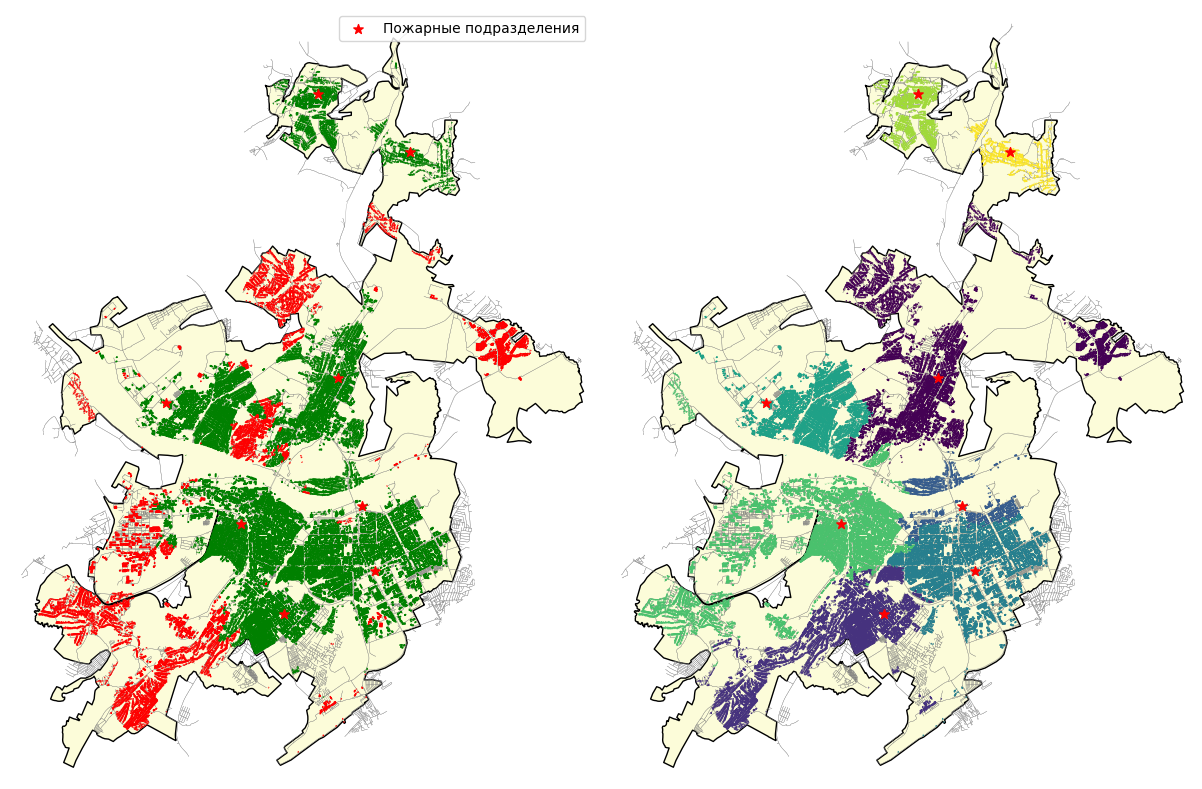

In [86]:
## Определение цветов зданий (требуется для лучшей читаемости при печати полигонов):
clrs = {k:v for k,v in zip(units['name'], ox.plot.get_colors(n=len(units)))}
bld_clrs = [clrs[n] for n in buildings['nearest']]


# Подготовка холста для 2 карт
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,8), tight_layout=True)

# Карта 10 минутной зоны
borders.plot(ax=ax1, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax1, close=False, show=False)
buildings[buildings['times']<=10].plot(ax=ax1, color='g', edgecolor='g') 
buildings[buildings['times']>10].plot(ax=ax1, color='r', edgecolor='r')
units.plot(ax=ax1, color='red', markersize=50, marker='*', label='Пожарные подразделения')
ax1.legend()

# Карта зон обслуживания
borders.plot(ax=ax2, color='#fcfcd9', edgecolor='black')
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, edge_color='gray', ax=ax2, close=False, show=False)
buildings.plot(ax=ax2, facecolor=bld_clrs, edgecolor=bld_clrs)
units.plot(ax=ax2, color='red', markersize=50, marker='*', label='Пожарные подразделения')

### Пример 4: Настройки скоростного режима {.unnumbered}

Стандартный подход к настройке скоростного режима подразумевает разделение всех типов дорог на 5 классов:

Список скоростей для 5 классов дорог:

1. Магистральные городские дороги и улицы общегородского значения
2. Магистральные улицы районного значения
3. Улицы и дороги местного значения
4. Служебные проезды: внутриквартальные, въездные, парковочные и т.д.
5. Пешеходные зоны и территории не являющиеся проезжей частью,
    но теоретически пригодные для передвижения пожарных автомобилей
        
Для их установки используется функция `set_graph_travel_times()`.

:::{.callout-warning}

#### Важно

Единицы измерения для подачи в set_graph_travel_times - [м/мин]. 
Стандартные же скорости указаны в [км/ч]. 
Поэтому необходимо выполнять преобразование единиц измерения [км/ч] -> [м/мин]!

:::

Наиболее общий пример - использовать скорости по умолчанию (из `graphs.settings.DEFAULT_SPEEDS`).

    speeds = [kmh_to_mm(s) for s in DEFAULT_SPEEDS]
    set_graph_travel_times(G, speeds)

или:

    set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)

In [90]:
from fire_units.settings import DEFAULT_SPEEDS

# Печать скоростей следования по разным классам дорог:
print(DEFAULT_SPEEDS)

# Или:
print('Магистральные городские дороги и улицы общегородского значения:    ', DEFAULT_SPEEDS[0], 'км/ч')
print('Магистральные улицы районного значения:                            ', DEFAULT_SPEEDS[1], 'км/ч')
print('Улицы и дороги местного значения:                                  ', DEFAULT_SPEEDS[2], 'км/ч')
print('Служебные проезды: внутриквартальные, въездные, парковочные и т.д.:', DEFAULT_SPEEDS[3], 'км/ч')
print('Пешеходные зоны и территории не являющиеся проезжей частью и т.д.: ', DEFAULT_SPEEDS[4], 'км/ч')

[49, 37, 26, 16, 5]
Магистральные городские дороги и улицы общегородского значения:     49 км/ч
Магистральные улицы районного значения:                             37 км/ч
Улицы и дороги местного значения:                                   26 км/ч
Служебные проезды: внутриквартальные, въездные, парковочные и т.д.: 16 км/ч
Пешеходные зоны и территории не являющиеся проезжей частью и т.д.:  5 км/ч


Примеры преобразования к м/мин

In [92]:
# Стандартный скоростной режим
print('км/ч:  ', DEFAULT_SPEEDS)
print('м/мин: ', [kmh_to_mm(s) for s in DEFAULT_SPEEDS])
print('-'*80)

# Пользовательский скоростной режим
def_speeds = [50, 40, 30, 20, 10]
print('км/ч:  ', def_speeds)
print('м/мин: ', [kmh_to_mm(s) for s in def_speeds])

км/ч:   [49, 37, 26, 16, 5]
м/мин:  [816.67, 616.67, 433.33, 266.67, 83.33]
--------------------------------------------------------------------------------
км/ч:   [50, 40, 30, 20, 10]
м/мин:  [833.33, 666.67, 500.0, 333.33, 166.67]


Расчет для нескольких скоростных режимов:

In [93]:
from genesis.states import FirstArrivalUnitState
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS

# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}


# 2. Сборка решения
## Выбор алгоритма моделирования 
## (алгоритмы расчета расчета кратчайшего пути
## и времени следования установлены по умолчанию)
state = FirstArrivalUnitState()

# 3. Моделирование параметров прибытия
# 3.1. Скоростной режим DEFAULT_SPEEDS: [49, 37, 26, 16, 5]
print('Скоростной режим:', DEFAULT_SPEEDS)
set_graph_travel_times(
    G,
    speeds         = DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)
times1, nearest1 = state(env=G, points=units_dict)
print(times1.describe(), end='\n\n')

# 3.2. Скоростной режим: [60, 45, 30, 15, 5]
print('Скоростной режим:', [60, 45, 30, 15, 5])
set_graph_travel_times(
    G,
    speeds         = [60, 45, 30, 15, 5],
    morph_function = kmh_to_mm)
times2, nearest2 = state(env=G, points=units_dict)
print(times2.describe(), end='\n\n')

# 3.3. Скоростной режим: [30, 25, 20, 15, 5]
print('Скоростной режим:', [30, 25, 20, 15, 5])
set_graph_travel_times(
    G,
    speeds         = [30, 25, 20, 15, 5],
    morph_function = kmh_to_mm)
times3, nearest3 = state(env=G, points=units_dict)
print(times3.describe(), end='\n\n')

Скоростной режим: [49, 37, 26, 16, 5]
count    54915.000000
mean        10.248943
std          5.993978
min          1.000000
25%          5.752797
50%          8.213621
75%         14.116574
max         35.690362
Name: times, dtype: float64

Скоростной режим: [60, 45, 30, 15, 5]
count    54915.000000
mean         8.940740
std          5.078279
min          1.000000
25%          5.108780
50%          7.226742
75%         12.423128
max         31.965563
Name: times, dtype: float64

Скоростной режим: [30, 25, 20, 15, 5]
count    54915.000000
mean        13.786360
std          8.474199
min          1.000000
25%          7.472917
50%         10.931034
75%         18.757200
max         48.919586
Name: times, dtype: float64



Text(0.5, 1.0, 'Скоростной режим:\n [30, 25, 20, 15, 5] км/ч\nСреднее время приб-я = 13.8 мин')

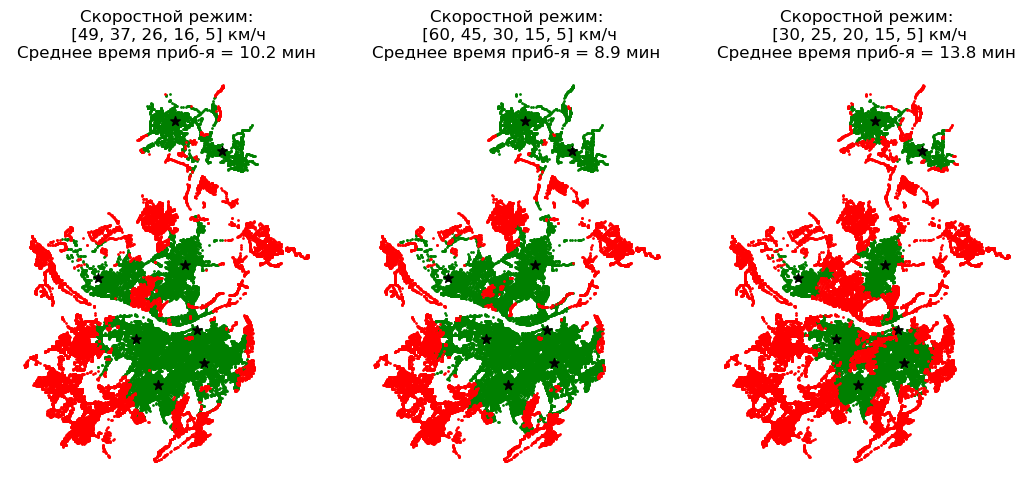

In [100]:
# Подготовка холста для 2 карт
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15,5), tight_layout=True)

# Карта скоростного режима 1
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes = g_nodes.merge(times1, left_index=True, right_index=True)

g_nodes[g_nodes['times']<=10].plot(ax=ax1, markersize=1, color='g') 
g_nodes[g_nodes['times']>10].plot(ax=ax1, markersize=1, color='r')
units.plot(ax=ax1, color='black', markersize=50, marker='*')
ax1.set_axis_off()
ax1.set_title(f'Скоростной режим:\n [49, 37, 26, 16, 5] км/ч\nСреднее время приб-я = {round(times1.mean(),1)} мин')


# Карта скоростного режима 2
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes = g_nodes.merge(times2, left_index=True, right_index=True)

g_nodes[g_nodes['times']<=10].plot(ax=ax2, markersize=1, color='g') 
g_nodes[g_nodes['times']>10].plot(ax=ax2, markersize=1, color='r')
units.plot(ax=ax2, color='black', markersize=50, marker='*')
ax2.set_axis_off()
ax2.set_title(f'Скоростной режим:\n [60, 45, 30, 15, 5] км/ч\nСреднее время приб-я = {round(times2.mean(),1)} мин')


# Карта скоростного режима 3
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes = g_nodes.merge(times3, left_index=True, right_index=True)

g_nodes[g_nodes['times']<=10].plot(ax=ax3, markersize=1, color='g') 
g_nodes[g_nodes['times']>10].plot(ax=ax3, markersize=1, color='r')
units.plot(ax=ax3, color='black', markersize=50, marker='*')
ax3.set_axis_off()
ax3.set_title(f'Скоростной режим:\n [30, 25, 20, 15, 5] км/ч\nСреднее время приб-я = {round(times3.mean(),1)} мин')

### Пример 5:

## Заключение

Здесь описан стандартный подход к изменению скоростного режима для 5 типов дорог. В случае если необходима более тонкая настройка скоростного режима рекомендуется обратиться к разделу "Для разработчиков".